In [ ]:
from typing import List, Optional
from functools import partial

import numpy as np
import pandas as pd

import plotly.express
import bokeh.plotting
import umap
import hdbscan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import optuna

from IPython.display import Image, display

import warnings

warnings.filterwarnings("ignore")

X = pd.read_parquet("aliens.parquet")
X

,alfa_popsize,eyebrow_length,fenistraline_length,leash_v2,jacket_size,poloka_dash,holy_spirit,postojka,durk_durk_3d,noopster,...,turilla_jet,weight,moonlight_shadow_angle,jister_ml,leg_pollution,wallet_size,biceps,aga,da,ankle_diameter
0,1273.210288,702.271017,352.754646,231.456804,135.162385,346.578535,70.388229,267.221799,162.812146,21.265403,...,12.817179,15.780798,3988.159803,15.027182,105.348660,77.565442,2231.976885,3356.206251,293.846039,1197.658371
1,1762.800555,552.176524,-348.578448,302.617511,66.096273,263.098188,-8.442866,199.800693,103.495658,29.978779,...,9.937281,12.075288,5292.966511,12.453356,86.882948,78.007788,3301.213697,5074.654575,351.400080,873.291874
2,1154.081932,1119.631765,-36.358379,200.098293,125.907321,334.439139,-20.265494,-519.780573,92.247154,29.199713,...,10.743006,8.756796,3856.035673,9.495362,116.418115,116.255086,3092.423116,3994.874963,335.185582,917.447816
3,1181.661571,1320.341225,293.866657,283.972621,93.459372,187.442851,89.402673,1378.205958,81.806588,35.836450,...,12.429817,11.421948,2717.142060,11.670682,131.664278,83.969841,3367.527054,2292.256561,351.901315,1074.534454
4,751.251638,998.132123,-724.730649,420.987379,60.963099,360.790557,-1.074858,1195.690980,121.554328,31.706275,...,12.065884,13.341130,3085.229342,9.853778,65.249706,100.545740,3612.973208,2899.235214,381.034647,1291.965098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1137.424408,688.857438,-90.263352,359.489998,129.683610,204.562443,-2.465434,-673.451138,95.645700,30.638093,...,11.031228,11.272852,853.655181,9.978489,67.999854,80.942708,3128.648509,2521.916972,324.780635,741.554471
9996,913.314659,859.295109,-530.187880,245.904131,77.807249,210.272221,25.786245,1590.171122,78.089080,37.442741,...,13.409530,13.714980,2348.817593,11.211519,126.782365,136.199706,3412.368087,3085.193759,371.102727,964.564360
9997,1133.345522,1042.954915,-755.420158,381.826616,116.520283,381.432154,18.509690,915.191240,89.055504,28.955985,...,12.424673,12.504124,2797.610181,11.842874,113.771209,76.383984,2972.426857,2482.928050,185.922537,956.117409
9998,713.240822,830.693428,-45.059154,262.265291,105.215648,321.509325,-19.198133,-647.714991,104.694268,36.520347,...,9.752806,9.727836,2166.196991,14.512985,75.965236,96.475552,4224.427711,1885.344082,320.413597,1465.775898


## 1. tool: EmbeddingPlotter (6 баллов)

Нужно написать функцию, которая принимает на вход 2D/3D эмбеддинг и отрисовывает его (можно и через класс).<br>
Требуемый функционал описан в докстринге.

Нужно заметить, что основные преимущества bokeh в этом задании не нужны, однако использование bokeh для 2D обязательно в целях минимального освоения.
В дальнейшем вы сможете усовершенствовать вашу рисовалку с помощью ColumnDataSource и коллбэков, если захотите.

In [2]:
def embedding_plotter(
    embedding: np.ndarray,
    data: pd.DataFrame,
    hue: Optional[str] = None,
    hover: Optional[List[str]] = None,
):
    """
    Рисовалка эмбеддинга. 2D renderer: bokeh. 3D renderer: plotly.
    Обязательные инструменты:
        - pan (двигать график)
        - box zoom
        - reset (вылезти из зума в начальное положение)

        embedding: something 2D/3D, slicable ~ embedding[:, 0] - валидно
            Эмбеддинг
        data: pd.DataFrame
            Данные, по которым был построен эмбеддинг
        hue: string
            Колонка из data, по которой красим точки. Поддерживает интерактивную легенду: по клику на каждое
                значение hue можно скрыть весь цвет.
        hover: string or list of strings
            Колонк[а/и] из data, значения которых нужно выводить при наведении мышки на точку

    """
    if hover is None:
        hover = []
    _, dim = embedding.shape

    if dim == 2:
        fig = bokeh.plotting.figure(width=800, height=600)

        if hue is not None:
            colors = bokeh.palettes.Category10_10
            for i, val in enumerate(data[hue].unique()):
                mask = data[hue] == val
                fig.scatter(
                    x="x",
                    y="y",
                    source=bokeh.models.ColumnDataSource(
                        data=dict(
                            x=embedding[mask, 0],
                            y=embedding[mask, 1],
                            **{col: data[mask][col] for col in hover},
                        )
                    ),
                    legend_label=f"{hue}={val}",
                    color=colors[i],
                )
        else:
            source = bokeh.models.ColumnDataSource(
                data=dict(
                    x=embedding[:, 0],
                    y=embedding[:, 1],
                    **{col: data[col] for col in hover},
                )
            )
            fig.scatter(x="x", y="y", source=source, legend_label="data")

        fig.legend.click_policy = "hide"
        if len(hover) > 0:
            fig.add_tools(
                bokeh.models.HoverTool(tooltips=[(col, f"@{col}") for col in hover])
            )

        bokeh.io.output_notebook()
        bokeh.plotting.show(fig)
        return

    if dim == 3:
        fig = plotly.express.scatter_3d(
            data_frame=data,
            x=embedding[:, 0],
            y=embedding[:, 1],
            z=embedding[:, 2],
            color=hue,
            hover_data=hover,
        )
        fig.update_traces(marker_size=1)
        fig.show()
        return

    raise NotImplementedError(f"Cannot plot data of dimension {dim}")

Приведите пример работы рисовалки на 2D и 3D данных. В качестве эмбеддингов возьмите какие-нибудь признаки из данных выше.

In [3]:
embeddings = X[["alfa_popsize", "eyebrow_length"]].to_numpy()
embedding_plotter(embeddings, X, hover=["holy_spirit"])

Loading BokehJS ...

In [4]:
embeddings = X[["alfa_popsize", "eyebrow_length", "fenistraline_length"]].to_numpy()
embedding_plotter(embeddings, X, hover=["holy_spirit"])

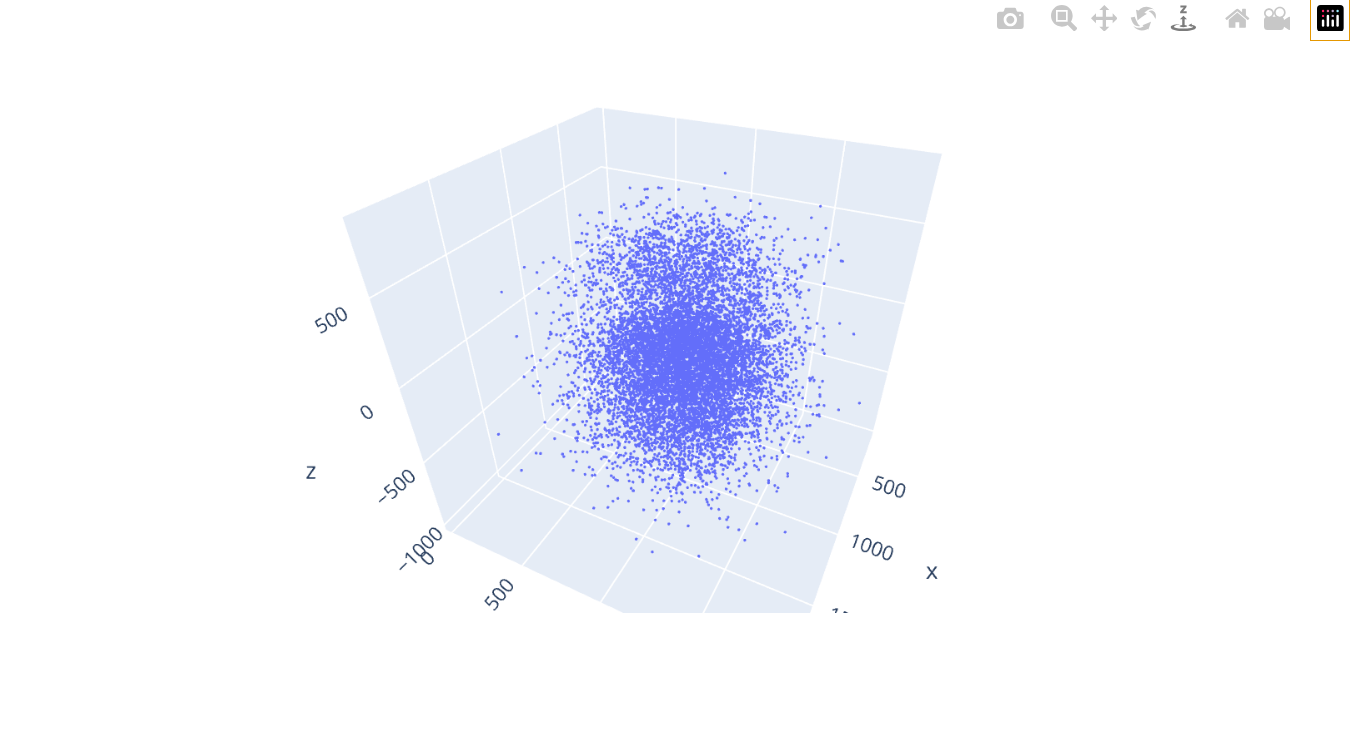

In [20]:
display(Image(filename="3d_plot.png"))

**! Если вы написали рисовалку, используйте ее в части 2 для отрисовки эмбеддингов**

## 2 Инопланетное вторжение

В разгар войны с инопланетянами в сеть утекли данные о десяти тысячах инопланетных особей, описанных странными показателями.
Никто не знает, что они значат, но все видят своими глазами, что среди инопланетян встречается пять существенно отличающихся видов, а также особи, которые трудно отнести к какому-либо виду.
Ваша задача по полученным данным произвести кибер-разведку и определить, к какому из видов относится каждый представленный в табличке субъект. Вы не знаете, как называются виды и чем именно из представленного в табличке они отличаются, но есть специалисты, готовые взять на себя подобную расшифровку.
Ваша задача - предоставить им разбиение данной таблички на кластеры (возможно, с шумом), чтобы они смогли начать анализ.

In [5]:
X.head()

,alfa_popsize,eyebrow_length,fenistraline_length,leash_v2,jacket_size,poloka_dash,holy_spirit,postojka,durk_durk_3d,noopster,...,turilla_jet,weight,moonlight_shadow_angle,jister_ml,leg_pollution,wallet_size,biceps,aga,da,ankle_diameter
0,1273.210288,702.271017,352.754646,231.456804,135.162385,346.578535,70.388229,267.221799,162.812146,21.265403,...,12.817179,15.780798,3988.159803,15.027182,105.348660,77.565442,2231.976885,3356.206251,293.846039,1197.658371
1,1762.800555,552.176524,-348.578448,302.617511,66.096273,263.098188,-8.442866,199.800693,103.495658,29.978779,...,9.937281,12.075288,5292.966511,12.453356,86.882948,78.007788,3301.213697,5074.654575,351.400080,873.291874
2,1154.081932,1119.631765,-36.358379,200.098293,125.907321,334.439139,-20.265494,-519.780573,92.247154,29.199713,...,10.743006,8.756796,3856.035673,9.495362,116.418115,116.255086,3092.423116,3994.874963,335.185582,917.447816
3,1181.661571,1320.341225,293.866657,283.972621,93.459372,187.442851,89.402673,1378.205958,81.806588,35.836450,...,12.429817,11.421948,2717.142060,11.670682,131.664278,83.969841,3367.527054,2292.256561,351.901315,1074.534454
4,751.251638,998.132123,-724.730649,420.987379,60.963099,360.790557,-1.074858,1195.690980,121.554328,31.706275,...,12.065884,13.341130,3085.229342,9.853778,65.249706,100.545740,3612.973208,2899.235214,381.034647,1291.965098


### 2.1 Понижение размерности (4 балла)

Чтобы быть уверенным в своей кластеризации, нужно иметь возможность посмотреть на нее глазами, поэтому для начала постараемся получить 2D-эмбеддинг нашей таблички.
Сделайте это на всех признаках с помощью PCA и t-SNE/UMAP с адекватными гиперпараметрами (2 разных картинки). Сделайте необходимую предобработку. Отрисуйте это вашей рисовалкой из первой части, если вы ее сделали. Что вы видите?

In [6]:
scaled_data = StandardScaler().fit_transform(X)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=50,
)
embedding_umap = umap_model.fit_transform(X)

pca_model = PCA(n_components=2)

embedding_pca = pca_model.fit_transform(scaled_data)

In [7]:
print("UMAP embedding")
embedding_plotter(embedding_umap, X)

UMAP embedding


Loading BokehJS ...

In [8]:
print("PCA embedding")
embedding_plotter(embedding_pca, X)

PCA embedding


Loading BokehJS ...

Фичи в пространствах обоих ембеддингов делятся на 3-4 явных кластера

Давайте попробуем улучшить ситуацию. Найдите любым кажущимся вам разумным способом (опишите, что делали) то подмножество признаков, по которому разные виды инопланетян могут отличаться.
Постройте и отрисуйте на этом подмножестве признаков такой 2D-эмбеддинг, на котором данные однозначным и убедительным образом делятся на 5 кластеров (чем отчетливей и убедительней, тем больше баллов :).
Для этого, возможно, придется поиграться с гиперпараметрами методов понижения размерности.

In [9]:
def get_data_subset(
    data: pd.DataFrame,
    pca_n_components: int = 2,
    threshold: float = 0.025,
) -> pd.DataFrame:
    scaled_data = StandardScaler().fit_transform(data)
    pca_model = PCA(n_components=pca_n_components)
    pca_model.fit(scaled_data)
    weights = np.abs(pca_model.components_).max(0)
    important_cols = data.columns[np.where(weights > threshold)[0]]
    return data[important_cols]


data_subset = get_data_subset(X)
scaled_data_subset = StandardScaler().fit_transform(data_subset)
umap_model_subset = umap.UMAP(
    n_components=2,
    n_neighbors=50,
)
embedding_umap_subset = umap_model_subset.fit_transform(data_subset)

pca_model_subset = PCA(n_components=2)
embedding_pca_subset = pca_model_subset.fit_transform(scaled_data_subset)

In [10]:
embedding_plotter(embedding_umap_subset, data_subset)

Loading BokehJS ...

In [11]:
embedding_plotter(embedding_pca_subset, data_subset)

Loading BokehJS ...

### 2.2 Кластеризация (5 баллов)

Давайте теперь разобьем получившийся эмбеддинг на кластеры. Для этого выберите алгоритм кластеризации, который по-вашему сможет справиться с задачей.
Объясните свой выбор, а также выбор гиперпараметров. Запустите кластеризацию и отрисуйте получившиеся кластеры. Сделайте так, чтобы кластеры получились максимально адекватными (чем адекватней, тем больше баллов :).

In [12]:
cluster = hdbscan.HDBSCAN()
cluster.fit(embedding_umap_subset)

data_subset.loc[:, "cluster"] = cluster.labels_
embedding_plotter(embedding_umap_subset, data_subset, hue="cluster")

Loading BokehJS ...

Теперь у нас есть кластеризация, которую можно отправить специалистам! Это почти все!

Напоследок, попробуйте получить такую же кластеризацию, запустив алгоритм на пространстве размерности больше трех. Выберите адекватное подмножество признаков и алгоритм.
Выберите метрику качества кластеризации, которую будете использовать. Объясните свой выбор.

In [13]:
umap_model_high_dim = umap.UMAP(
    n_components=10,
    n_neighbors=50,
)

embedding_umap_high_dim = umap_model_high_dim.fit_transform(data_subset)
cluster_high_dim = hdbscan.HDBSCAN()
cluster_high_dim.fit(embedding_umap_high_dim)

HDBSCAN()

Одна из популярных метрик - `silhouette`
$$ \frac{1}{N} \sum_i^N \frac{\mathrm{d}(x_i, c_2) - \mathrm{d}(x_i, c_1)}{\max(\mathrm{d}(x_i, c_2), \mathrm{d}(x_i, c_1))} $$

Которая пропорциональна разнице расстояний между вторым и первым кластерами в топе, а также отнормированна по максимальной дистанции до этих кластеров (что снижает вес для слишком удалённых кластеров). Она мне показалось наиболее интуитивно понятной, а также достаточно репрезентативной

In [14]:
print(
    f"Silhouette score on 10 dim umap: {silhouette_score(X, cluster_high_dim.labels_)}"
)
print(f"Silhouette score on 2 dim umap: {silhouette_score(X, cluster.labels_)}")

Silhouette score on 10 dim umap: 0.10739568827066853
Silhouette score on 2 dim umap: 0.10781715160276215


Как видно, разница в метрике очень мала для различных размерностей в эмбеддинге

С помощью optuna подберите гиперпараметры, которые дают наилучшую метрику качества кластеризации (нужно попробовать не менее 21 различных адекватных вариантов).
Запустите алгоритм кластеризации с наилучшими гиперпараметрами на выбранном подмножестве признаков и отрисуйте получившиеся кластеры на вашем полученном в части 2.1 эмбеддинге.

In [15]:
def objective(trial: optuna.Trial, data: pd.DataFrame):
    # Selection params
    pca_n_components = trial.suggest_int("pca_n_components", 2, 15)
    threshold = trial.suggest_float("threshold", 0.01, 0.5, log=True)

    # Embedding params
    n_neighbors = trial.suggest_int("n_neighbors", 5, 100)
    n_components = trial.suggest_int("n_components", 2, 10)

    # Cluster params
    min_cluster_size = trial.suggest_int("min_cluster_size", 10, 1000)
    min_samples = trial.suggest_int("min_samples", 3, 500)
    cluster_selection_epsilon = trial.suggest_float(
        "cluster_selection_epsilon", 0.01, 5.0, log=True
    )

    data_subset = get_data_subset(
        data, pca_n_components=pca_n_components, threshold=threshold
    )

    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
    )

    embedding_umap = umap_model.fit_transform(data_subset)

    cluster = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
    )
    cluster.fit(embedding_umap)

    metric = silhouette_score(data, cluster.labels_) 
    # Регуляризируем метрику, чтобы неадекватные гиперпараметры не давали неверного числа кластеров 
    regularization = -10 * (len(np.unique(cluster.labels_)) != 3) 
    return metric + regularization


objective = partial(objective, data=X)

sampler = optuna.samplers.TPESampler(multivariate=True, n_startup_trials=15)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=25, n_jobs=3)

[I 2024-12-22 19:48:07,495] A new study created in memory with name: no-name-4667cece-dcdc-4abc-9522-860b88f3f68e
[I 2024-12-22 19:48:27,231] Trial 0 finished with value: 0.10792099098719297 and parameters: {'pca_n_components': 3, 'threshold': 0.09328637054446084, 'n_neighbors': 19, 'n_components': 9, 'min_cluster_size': 849, 'min_samples': 409, 'cluster_selection_epsilon': 0.17477700780101707}. Best is trial 0 with value: 0.10792099098719297.
[I 2024-12-22 19:48:30,911] Trial 2 finished with value: -9.920158574755103 and parameters: {'pca_n_components': 15, 'threshold': 0.08150613551750946, 'n_neighbors': 70, 'n_components': 6, 'min_cluster_size': 136, 'min_samples': 43, 'cluster_selection_epsilon': 0.02691286172784847}. Best is trial 0 with value: 0.10792099098719297.
[I 2024-12-22 19:48:35,477] Trial 1 finished with value: 0.09867521234728117 and parameters: {'pca_n_components': 8, 'threshold': 0.013690670614390407, 'n_neighbors': 94, 'n_components': 5, 'min_cluster_size': 257, 'min

In [17]:
params = study.best_params

pca_n_components = params["pca_n_components"]
threshold = params["threshold"]

n_neighbors = params["n_neighbors"]
n_components = params["n_components"]

min_cluster_size = params["min_cluster_size"]
min_samples = params["min_samples"]
cluster_selection_epsilon = params["cluster_selection_epsilon"]

data_subset_best = get_data_subset(
    X,
    pca_n_components=pca_n_components,
    threshold=threshold,
)

umap_model_best = umap.UMAP(
    n_neighbors=n_neighbors,
    n_components=n_components,
)
umap_model_2d = umap.UMAP(
    n_neighbors=50,
    n_components=2,
)

embedding_umap_best = umap_model_best.fit_transform(data_subset_best)
embedding_umap_2d = umap_model_2d.fit_transform(X)

cluster_best = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    cluster_selection_epsilon=cluster_selection_epsilon,
)
cluster_best.fit(embedding_umap_best)

X.loc[:, "cluster"] = cluster_best.labels_
embedding_plotter(embedding_umap_2d, X, hue="cluster")

Loading BokehJS ...

Какие выводы можно сделать из увиденного?

### Выводы
По моим наблюдениям, данные очень чётко делятся на 3 кластера видов инопланетян: при различных гиперпараметрах, значение `silhouette` метрики не сильно меняется, а при лучших найденных параметрах картинка в `2D` представлении практически идентична с первоначальным изображением

# Ура! Всем хорошего нового года!  |:--)